<a href="https://colab.research.google.com/github/japmanyakaur/early-disease-detection-in-crops/blob/main/crop_disease_DEMO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Crop Disease Demo — v3

## Section 1 — Mount Drive & find your trained weights

This searches your whole `crop-disease-model/` folder for any `*_final.pt` file,
so it works regardless of which notebook version produced them.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os, glob

SEARCH_ROOT = '/content/drive/MyDrive/crop-disease-model'

all_final_models = glob.glob(f'{SEARCH_ROOT}/**/*_final.pt', recursive=True)
print(f'Found {len(all_final_models)} final model file(s) under {SEARCH_ROOT}:\n')
for p in sorted(all_final_models):
    size_mb = os.path.getsize(p) / (1024 * 1024)
    print(f'  {p}   ({size_mb:.1f} MB)')

if not all_final_models:
    print('\nNo *_final.pt files found. Check that v9 (or whichever notebook you trained with)')
    print('actually finished and saved final models, and that this Colab is signed into the')
    print('same Google account whose Drive holds them.')


Mounted at /content/drive
Found 10 final model file(s) under /content/drive/MyDrive/crop-disease-model:

  /content/drive/MyDrive/crop-disease-model/_archive_pre_v9/grape_mobilenetv3_large_100_final.pt   (16.3 MB)
  /content/drive/MyDrive/crop-disease-model/_archive_pre_v9/grape_model_final.pt   (16.2 MB)
  /content/drive/MyDrive/crop-disease-model/_archive_pre_v9/grape_resnet50_final.pt   (90.0 MB)
  /content/drive/MyDrive/crop-disease-model/_archive_pre_v9/tomato_mobilenetv3_large_100_final.pt   (16.3 MB)
  /content/drive/MyDrive/crop-disease-model/_archive_pre_v9/tomato_model_final.pt   (16.3 MB)
  /content/drive/MyDrive/crop-disease-model/_archive_pre_v9/tomato_resnet50_final.pt   (90.1 MB)
  /content/drive/MyDrive/crop-disease-model/v9_final/grape_mobilenetv3_large_100_final.pt   (16.3 MB)
  /content/drive/MyDrive/crop-disease-model/v9_final/grape_resnet50_final.pt   (90.0 MB)
  /content/drive/MyDrive/crop-disease-model/v9_final/tomato_mobilenetv3_large_100_final.pt   (16.3 MB)
  

## Section 2 — Pick weight files to load



In [2]:
TOMATO_MOBILENET_PATH = f'{SEARCH_ROOT}/v9_final/final_models/tomato_mobilenetv3_large_100_final.pt'
TOMATO_RESNET_PATH    = f'{SEARCH_ROOT}/v9_final/final_models/tomato_resnet50_final.pt'
GRAPE_MOBILENET_PATH  = f'{SEARCH_ROOT}/v9_final/final_models/grape_mobilenetv3_large_100_final.pt'

# If any of these don't exist, try to auto-locate the closest match from Section 1's list
def resolve(path, keyword):
    if os.path.exists(path):
        return path
    candidates = [p for p in all_final_models if keyword in os.path.basename(p).lower()]
    if candidates:
        print(f'{path} not found — using closest match instead: {candidates[0]}')
        return candidates[0]
    print(f'WARNING: could not find a model matching {keyword!r}. Prediction for that model will fail.')
    return path

TOMATO_MOBILENET_PATH = resolve(TOMATO_MOBILENET_PATH, 'tomato_mobilenetv3')
TOMATO_RESNET_PATH = resolve(TOMATO_RESNET_PATH, 'tomato_resnet')
GRAPE_MOBILENET_PATH = resolve(GRAPE_MOBILENET_PATH, 'grape_mobilenetv3')


/content/drive/MyDrive/crop-disease-model/v9_final/final_models/tomato_mobilenetv3_large_100_final.pt not found — using closest match instead: /content/drive/MyDrive/crop-disease-model/v9_final/tomato_mobilenetv3_large_100_final.pt
/content/drive/MyDrive/crop-disease-model/v9_final/final_models/tomato_resnet50_final.pt not found — using closest match instead: /content/drive/MyDrive/crop-disease-model/v9_final/tomato_resnet50_final.pt
/content/drive/MyDrive/crop-disease-model/v9_final/final_models/grape_mobilenetv3_large_100_final.pt not found — using closest match instead: /content/drive/MyDrive/crop-disease-model/v9_final/grape_mobilenetv3_large_100_final.pt


## Section 3 — Install deps & define classes / model loader

In [7]:
!pip install -q timm grad-cam
print('done')


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 2.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
done


In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import timm
from torchvision import transforms
from PIL import Image as PILImage
import matplotlib.pyplot as plt
import numpy as np

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
IMG_SIZE = 224
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

eval_tfm = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

TOMATO_CLASSES = [
    'Tomato___Bacterial_spot',
    'Tomato___Early_blight',
    'Tomato___Late_blight',
    'Tomato___Leaf_Mold',
    'Tomato___Septoria_leaf_spot',
    'Tomato___Spider_mites Two-spotted_spider_mite',
    'Tomato___Target_Spot',
    'Tomato___Tomato_Yellow_Leaf_Curl_Virus',
    'Tomato___Tomato_mosaic_virus',
    'Tomato___healthy',
]
GRAPE_CLASSES = [
    'Grape___Black_rot',
    'Grape___Esca_(Black_Measles)',
    'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)',
    'Grape___healthy',
]
CROP_CLASSES = {'tomato': TOMATO_CLASSES, 'grape': GRAPE_CLASSES}

def load_model(path, arch_name, num_classes):
    model = timm.create_model(arch_name, pretrained=False, num_classes=num_classes)
    state = torch.load(path, map_location=DEVICE)
    model.load_state_dict(state)
    model.to(DEVICE).eval()
    return model

tomato_models, grape_models = [], []
try:
    tomato_models.append(('mobilenetv3_large_100', load_model(TOMATO_MOBILENET_PATH, 'mobilenetv3_large_100', len(TOMATO_CLASSES))))
    print('Loaded tomato MobileNetV3.')
except Exception as e:
    print('Could not load tomato MobileNetV3:', e)
try:
    tomato_models.append(('resnet50', load_model(TOMATO_RESNET_PATH, 'resnet50', len(TOMATO_CLASSES))))
    print('Loaded tomato ResNet50.')
except Exception as e:
    print('Could not load tomato ResNet50:', e)
try:
    grape_models.append(('mobilenetv3_large_100', load_model(GRAPE_MOBILENET_PATH, 'mobilenetv3_large_100', len(GRAPE_CLASSES))))
    print('Loaded grape MobileNetV3.')
except Exception as e:
    print('Could not load grape MobileNetV3:', e)

print(f'\nReady: {len(tomato_models)} tomato model(s), {len(grape_models)} grape model(s) loaded.')


Loaded tomato MobileNetV3.
Loaded tomato ResNet50.
Loaded grape MobileNetV3.

Ready: 2 tomato model(s), 1 grape model(s) loaded.


## Section 4 — Predict function (upload from your computer)

Ensemble-averages whatever models loaded successfully for that crop (matches the
config that scored best in your evidence table: tomato = ensemble, grape = single
model) and shows the top-5 confidences plus a Grad-CAM box of where it looked.

In [10]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

def get_cam_target_layer(model, arch_name):
    if 'resnet' in arch_name:
        return [model.layer4[-1]]
    if 'mobilenet' in arch_name:
        return [model.blocks[-1]]
    raise ValueError(f'No known CAM target layer for {arch_name}')

def predict_and_show(image_path, crop):
    assert crop in ('tomato', 'grape'), "crop must be 'tomato' or 'grape'"
    classes = CROP_CLASSES[crop]
    models = tomato_models if crop == 'tomato' else grape_models
    if not models:
        print(f'No {crop} models loaded — check Section 1/2 paths.')
        return

    img = PILImage.open(image_path).convert('RGB')
    x = eval_tfm(img).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        probs_sum = sum(F.softmax(m(x), dim=1) for _, m in models) / len(models)
    probs = probs_sum[0]
    top_idx = int(probs.argmax().item())

    arch_name, cam_model = models[0]
    cam = GradCAM(model=cam_model, target_layers=get_cam_target_layer(cam_model, arch_name))
    targets = [ClassifierOutputTarget(top_idx)]
    grayscale_cam = cam(input_tensor=x, targets=targets)[0]
    img_resized = np.array(img.resize((IMG_SIZE, IMG_SIZE))).astype(np.float32) / 255.0
    cam_overlay = show_cam_on_image(img_resized, grayscale_cam, use_rgb=True)

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(img)
    axes[0].axis('off')
    axes[0].set_title('Uploaded image')
    axes[1].imshow(cam_overlay)
    axes[1].axis('off')
    axes[1].set_title('Where the model looked (Grad-CAM)')
    plt.suptitle(f'{classes[top_idx]}  —  {probs[top_idx]*100:.1f}% confidence', fontsize=13)
    plt.tight_layout()
    plt.show()

    print('Top-5 predictions:')
    top5 = probs.topk(min(5, len(classes)))
    for idx, p in zip(top5.indices.tolist(), top5.values.tolist()):
        print(f'  {classes[idx]:50s} {p*100:5.1f}%')

## Section 5 — Upload & predict (run this cell each time you want to test a new photo)

Works for **any** photo — a clean lab-style photo or a messy real/cluttered one from
your phone gallery. Set `crop` to `'tomato'` or `'grape'` to match the leaf you're
uploading.

Upload a tomato leaf photo from your computer:


Saving tomato-septoria-leaf-spot-grabowski.jpg to tomato-septoria-leaf-spot-grabowski (2).jpg


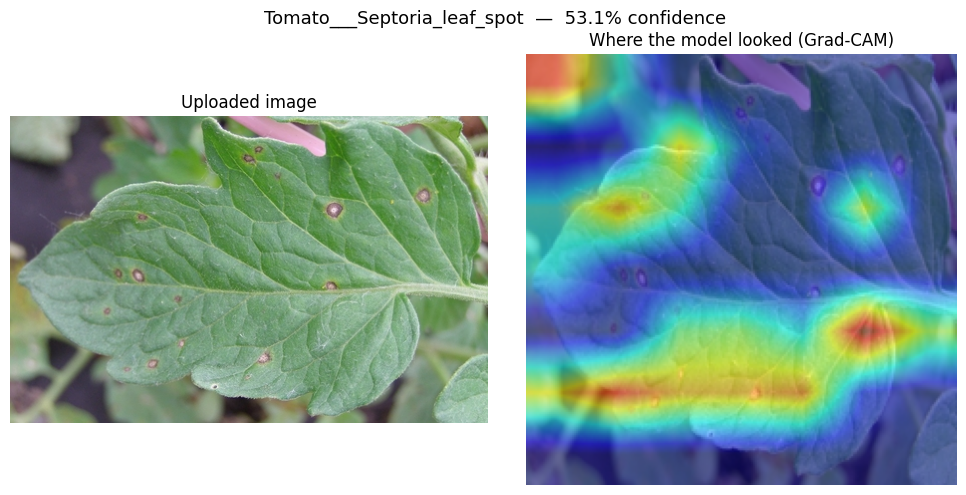

Top-5 predictions:
  Tomato___Septoria_leaf_spot                         53.1%
  Tomato___healthy                                    23.3%
  Tomato___Leaf_Mold                                  11.0%
  Tomato___Bacterial_spot                              4.4%
  Tomato___Late_blight                                 3.7%


In [13]:
from google.colab import files

crop = 'tomato'  # change to 'grape' as needed

print(f'Upload a {crop} leaf photo from your computer:')
uploaded = files.upload()
uploaded_path = list(uploaded.keys())[0]
predict_and_show(uploaded_path, crop=crop)


## Section 6 — Quick backup: random sample from cached datasets

If the upload widget misbehaves during a live demo (venue wifi, browser quirks),
this is a fallback that pulls a random image from whatever dataset cache already
exists in Drive from your training runs — lab (clean) or field (cluttered) — so
you always have something ready to show.

In [ ]:
import random

def find_dataset_root():
    candidates = glob.glob(f'{SEARCH_ROOT}/*/data_cache') + glob.glob(f'{SEARCH_ROOT}/*_final/data_cache')
    return candidates[0] if candidates else None

DATASET_ROOT = find_dataset_root()
print('Using cached dataset at:', DATASET_ROOT)

def random_demo(crop, split):
    """split: 'lab_val' for clean lab photos, 'field_eval' for real cluttered photos."""
    if DATASET_ROOT is None:
        print('No cached dataset folder found — use Section 5 (upload) instead.')
        return
    imgs = glob.glob(f'{DATASET_ROOT}/{crop}/{split}/*/*')
    if not imgs:
        print(f'No images found under {crop}/{split}.')
        return
    path = random.choice(imgs)
    predict_and_show(path, crop=crop)

# Examples:
random_demo('tomato', 'lab_val')
# random_demo('tomato', 'field_eval')
# random_demo('grape', 'lab_val')
# random_demo('grape', 'field_eval')
